In [1]:
#RNN

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("GOOGL.csv")

In [6]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659096
1,2004-08-20,50.555557,54.594597,50.300301,54.209209,54.209209,22834343
2,2004-08-23,55.430431,56.796799,54.579578,54.754753,54.754753,18256126
3,2004-08-24,55.675674,55.855858,51.836838,52.487488,52.487488,15247337
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188602


In [7]:
df.shape

(4431, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4431 entries, 0 to 4430
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4431 non-null   object 
 1   Open       4431 non-null   float64
 2   High       4431 non-null   float64
 3   Low        4431 non-null   float64
 4   Close      4431 non-null   float64
 5   Adj Close  4431 non-null   float64
 6   Volume     4431 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 242.4+ KB


In [9]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

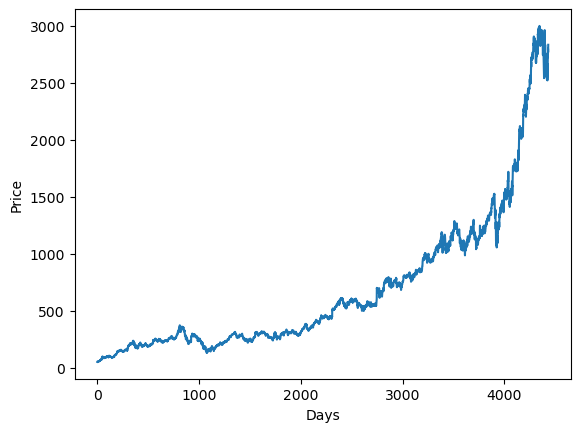

In [11]:
plt.figure()
plt.plot(df['Close'])
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()
         

In [12]:
data = df[["Close"]]

In [13]:
from sklearn.preprocessing import MinMaxScaler

In [14]:
# Create scaler object
scaler = MinMaxScaler()

In [15]:
# Scale the data
scaled_data = scaler.fit_transform(data)

In [16]:
x = []
y = []

In [17]:
for i in range(60 , len(scaled_data)):
    x.append(scaled_data[i-60:i])
    y.append(scaled_data[i])
    

In [18]:
x = np.array(x)

In [19]:
y = np.array(y)

In [20]:
x.shape

(4371, 60, 1)

In [21]:
y.shape

(4371, 1)

In [22]:
split = int(len(x)*0.8)

In [23]:
x_train = x[:split]

In [24]:
x_test = x[split:]

In [25]:
y_train = y[:split]

In [26]:
y_test = y[split:]

In [27]:
from tensorflow.keras.models import Sequential

In [28]:
from tensorflow.keras.layers import SimpleRNN

In [29]:
from tensorflow.keras.layers import Dense

In [30]:
model = Sequential()

In [31]:
model.add(
    SimpleRNN(
        units=50,
        activation="tanh",
        input_shape=(60, 1)
    )
)

D:\anaconda- summer-june\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
model.add(Dense(1))

In [33]:
model.compile(
    optimizer = "adam",
    loss = 'mean_squared_error'
)

In [34]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0049 - val_loss: 0.0736
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.8321e-04 - val_loss: 0.0318
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 6.3517e-05 - val_loss: 0.0154
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 5.4579e-05 - val_loss: 0.0155
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 4.8054e-05 - val_loss: 0.0139
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 4.3238e-05 - val_loss: 0.0128
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 4.4523e-05 - val_loss: 0.0128
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 3.9895e-05 - val_loss: 0.0110
Epoch 9/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 3.9602e-05 - val_loss: 0.0103
Epoch 10/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 3.9162e-05 - val_loss: 0.0106
Epoch 11/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 3.9669e-05 - val_loss: 0.0083
E

In [35]:
predict = model.predict(x_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step


In [36]:
model_predictions = scaler.inverse_transform(predict)

In [37]:
actual = scaler.inverse_transform(y_test)

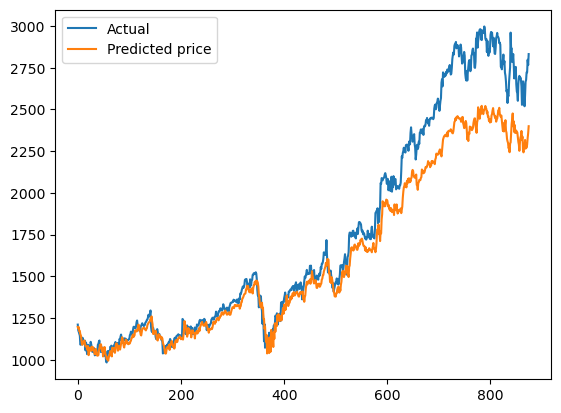

In [38]:
plt.figure()
plt.plot(actual , label = "Actual")
plt.plot(model_predictions, label = "Predicted price")

plt.legend()
plt.show()

In [39]:
# reinforcement learning

In [40]:
!pip install gymnasium

In [41]:
import gymnasium as gym

In [42]:
env = gym.make("Taxi-v4")

In [43]:
state , info = env.reset()

In [44]:
print(state)

28


In [45]:
print(info)

{'prob': 1.0, 'action_mask': array([1, 0, 0, 1, 0, 0], dtype=int8)}


In [46]:
print(env.render())

None


D:\anaconda- summer-june\Lib\site-packages\gymnasium\envs\toy_text\taxi.py:481: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("Taxi-v4", render_mode="rgb_array")
  gym.logger.warn(


In [47]:
env = gym.make("Taxi-v4" , render_mode="ansi")

In [48]:
state , info = env.reset()
print(env.render())

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




In [49]:
print(env.observation_space)

Discrete(500)


In [50]:
print(env.action_space)

Discrete(6)


In [51]:
action = env.action_space.sample()

In [52]:
print(action)

0


In [53]:
next_state , reward , terminated , truncated , info = env.step(action)

In [54]:
print(next_state)

492


In [55]:
print(reward)

-1


In [56]:
print(terminated)

False


In [57]:
import numpy as np

In [58]:
q_table = np.zeros((500 , 6))

In [59]:
alpha = 0.1
gamma = 0.9
epsilon = 0.1
episodes = 1000

In [60]:
for episode in range(episodes):
    state , info = env.reset()
    done = False
    while not done:
        if np.random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])
            
        next_state, reward, terminated, truncated, info = env.step(action)   
        old_value = q_table[state , action]
        nex_max = np.max(q_table[next_state])
        new_value = old_value + alpha *(reward + gamma * nex_max - old_value)
        q_table[state , action] = new_value
        state = next_state
        done = terminated or truncated


In [61]:
state , info = env.reset()

In [62]:
done = False
total_reward = 0

In [ ]:
while not done:
    action = np.argmax(q_table[state])
    next_state, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    state = next_state
    one = terminated or truncated

print("Test Completed")
print("Total Reward:" , total_reward)


In [ ]:
env = gym.make("Taxi-v4" , rendor_mode = "ansi")
state , info = env.reset()

done = False
total_reward = 0

while not done:
    action = np.argmax(q_table[state])
    next_state, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    state = next_state
    one = terminated or truncated

print("Total Reward:" , total_reward)
evn.close